In [2]:
import pandas as pd

san_antonio_final = pd.read_csv('/Users/arjunrajesh/Downloads/teamb_final_data.csv')

san_antonio_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824051 entries, 0 to 824050
Data columns (total 31 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   datetime                                            824050 non-null  object 
 1   lat                                                 824051 non-null  float64
 2   lng                                                 824051 non-null  float64
 3   district                                            816952 non-null  float64
 4   subject_age                                         823576 non-null  float64
 5   violation                                           824051 non-null  object 
 6   violation_embedded                                  824051 non-null  object 
 7   arrest_made                                         824051 non-null  int64  
 8   citation_issued                                     824051 non-n

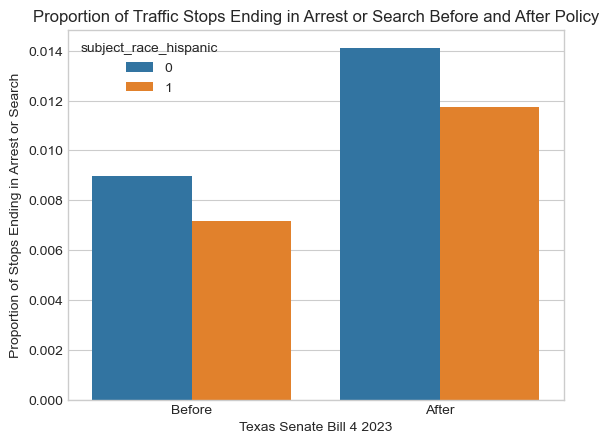

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

prop=san_antonio_final.groupby(['texas_sb_4_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='texas_sb_4_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Texas Senate Bill 4 2023')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])
plt.show()

#Allows the state of texas rather than federal judges to send individuals back to their country of origin if they're illegal. State Crime



([<matplotlib.axis.XTick at 0x32287a710>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

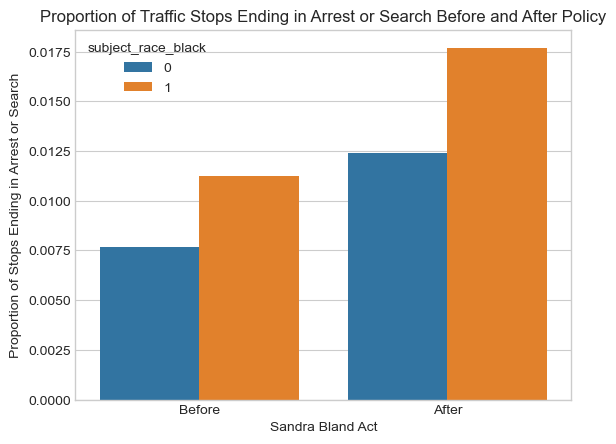

In [4]:
prop=san_antonio_final.groupby(['sandra_bland_act_active','subject_race_black'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='sandra_bland_act_active',y='extreme_cases',hue='subject_race_black')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Sandra Bland Act')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])
#Sandra got pulled for failed to to put blinker on, interaction became heated and arrested. Struggling needed to leave prison, but couldn't make bail, found deceased in jail cell.
#After that Sandra Bland Act implemented explicilty outlawed stupid stops


([<matplotlib.axis.XTick at 0x322934050>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

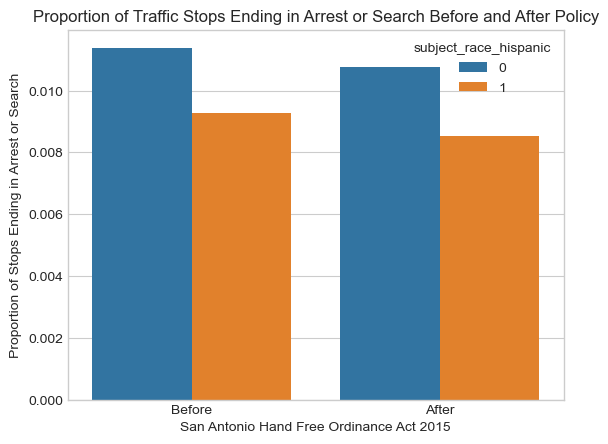

In [5]:
prop=san_antonio_final.groupby(['san_antonio_hands-free_ordinance_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='san_antonio_hands-free_ordinance_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('San Antonio Hand Free Ordinance Act 2015')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

([<matplotlib.axis.XTick at 0x3228b0f50>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

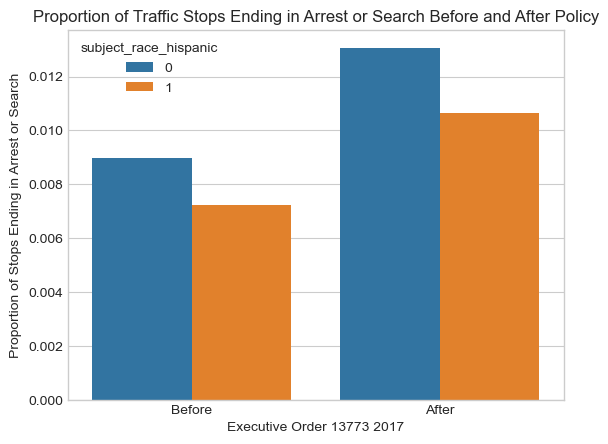

In [6]:
prop=san_antonio_final.groupby(['eo_13773_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='eo_13773_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Executive Order 13773 2017')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

([<matplotlib.axis.XTick at 0x3229f20d0>,
 [Text(0, 0, 'Before'), Text(1, 0, 'After')])

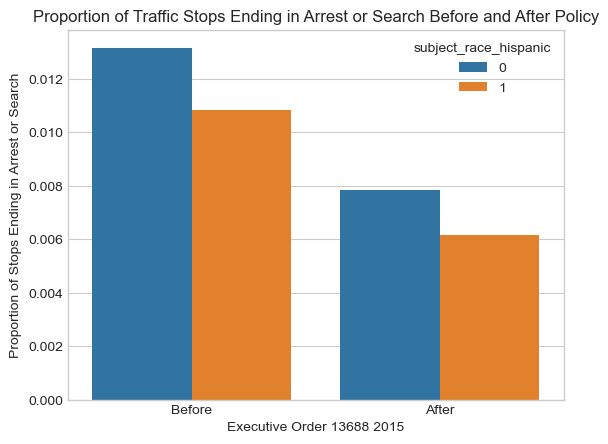

In [7]:
prop=san_antonio_final.groupby(['eo_13688_active','subject_race_hispanic'])['extreme_cases'].mean().reset_index()
sns.barplot(data=prop,x='eo_13688_active',y='extreme_cases',hue='subject_race_hispanic')
plt.title('Proportion of Traffic Stops Ending in Arrest or Search Before and After Policy')
plt.xlabel('Executive Order 13688 2015')
plt.ylabel('Proportion of Stops Ending in Arrest or Search')
plt.xticks(ticks=[0,1],labels=['Before','After'])

In [8]:

def get_race(row):
    if row['subject_race_black'] == 1: return 'Black'
    if row['subject_race_hispanic'] == 1: return 'Hispanic'
    if row['subject_race_white'] == 1: return 'White'
    if row['subject_race_other'] == 1: return 'Other'
    return 'Unknown'

san_antonio_final['subject_race'] = san_antonio_final.apply(get_race, axis=1)


san_antonio_final['datetime'] = pd.to_datetime(san_antonio_final['datetime'])



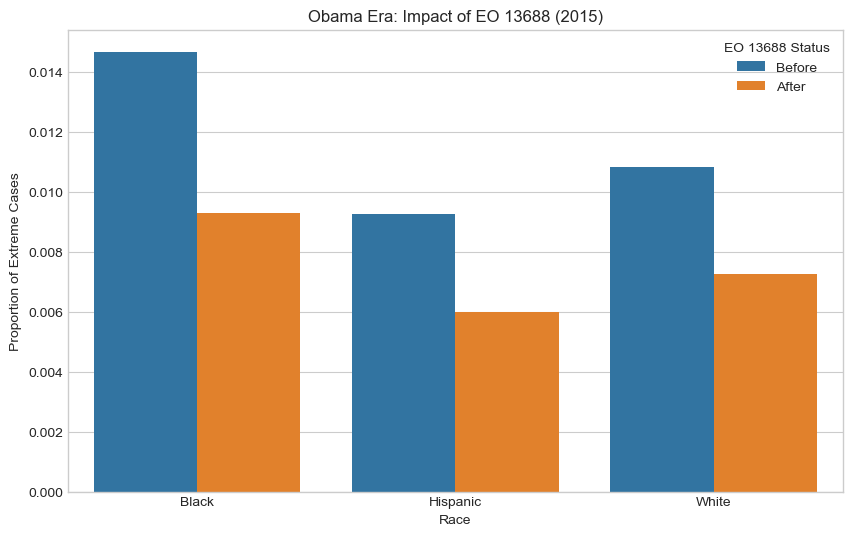

In [9]:
# 1. Filter for Obama years
obama_era = san_antonio_final[san_antonio_final['datetime'].dt.year <= 2016]

# 2. Group the data and FILTER for only Black, Hispanic, and White
prop_obama = obama_era[obama_era['subject_race'].isin(['Black', 'Hispanic', 'White'])].groupby(
    ['subject_race', 'eo_13688_active']
)['extreme_cases'].mean().reset_index()

# 3. Plot it
plt.figure(figsize=(10,6))
sns.barplot(data=prop_obama, x='subject_race', y='extreme_cases', hue='eo_13688_active')

plt.title('Obama Era: Impact of EO 13688 (2015)')
plt.xlabel('Race') 
plt.ylabel('Proportion of Extreme Cases')

# Fix the legend
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Before', 'After'], title='EO 13688 Status')

plt.show()




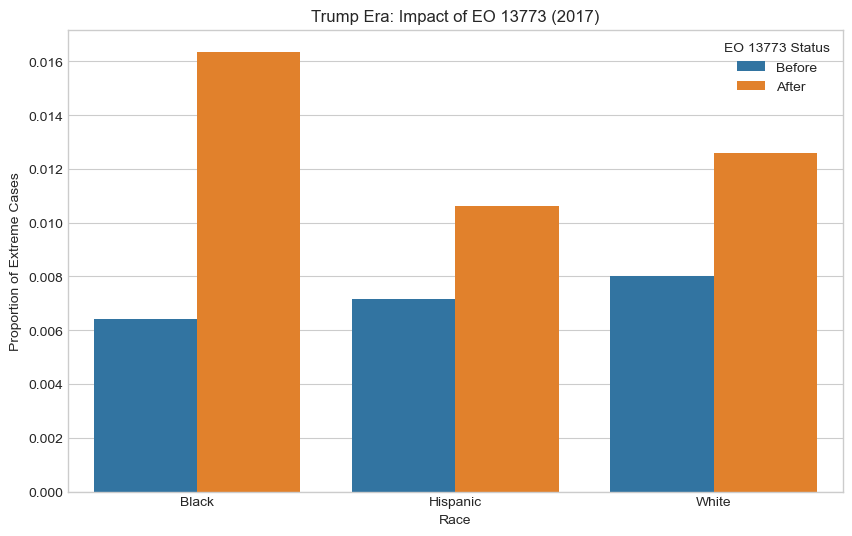

In [10]:
# 1. Filter for Trump years (2017-2019)
trump_era = san_antonio_final[san_antonio_final['datetime'].dt.year >= 2017]

# 2. Group the data and FILTER for only Black, Hispanic, and White
prop_trump = trump_era[trump_era['subject_race'].isin(['Black', 'Hispanic', 'White'])].groupby(
    ['subject_race', 'eo_13773_active']
)['extreme_cases'].mean().reset_index()


plt.figure(figsize=(10,6))
sns.barplot(data=prop_trump, x='subject_race', y='extreme_cases', hue='eo_13773_active')

plt.title('Trump Era: Impact of EO 13773 (2017)')
plt.xlabel('Race') 
plt.ylabel('Proportion of Extreme Cases')


handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Before', 'After'], title='EO 13773 Status')

plt.show()



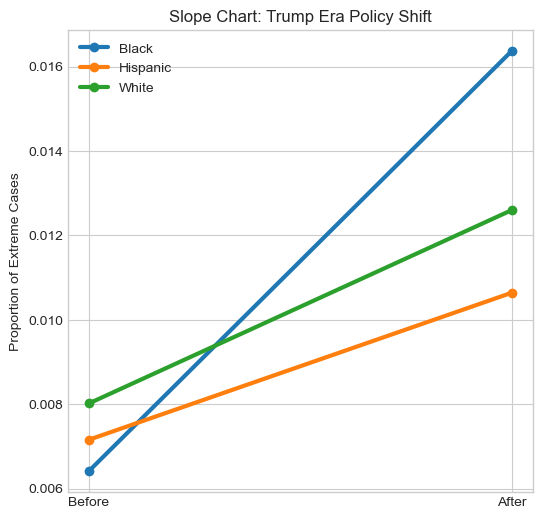

In [11]:

plt.figure(figsize=(6, 6))
for race in ['Black', 'Hispanic', 'White']:
    subset = prop_trump[prop_trump['subject_race'] == race]
    # 'eo_13773_active' 0 is Before, 1 is After
    plt.plot(['Before', 'After'], subset['extreme_cases'], marker='o', label=race, linewidth=3)

plt.title('Slope Chart: Trump Era Policy Shift')
plt.ylabel('Proportion of Extreme Cases')
plt.legend()
plt.show()

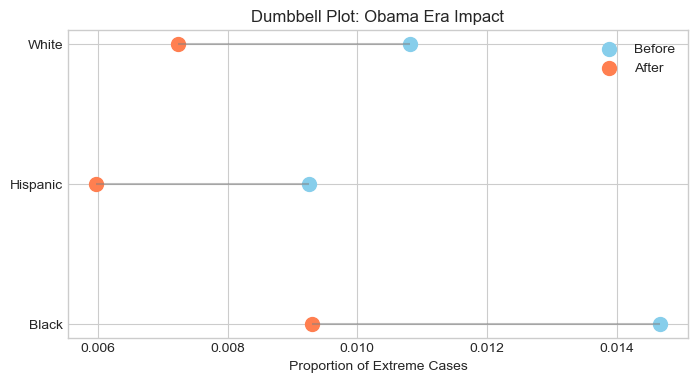

In [12]:
plt.figure(figsize=(8, 4))
for i, race in enumerate(['Black', 'Hispanic', 'White']):
    # Get values for Before (0) and After (1)
    before = prop_obama[(prop_obama['subject_race']==race) & (prop_obama['eo_13688_active']==0)]['extreme_cases'].values[0]
    after = prop_obama[(prop_obama['subject_race']==race) & (prop_obama['eo_13688_active']==1)]['extreme_cases'].values[0]
    
    # Draw the line (the bar of the dumbbell)
    plt.hlines(y=race, xmin=before, xmax=after, color='grey', alpha=0.5)
    # Draw the dots
    plt.scatter(before, race, color='skyblue', s=100, label='Before' if i == 0 else "")
    plt.scatter(after, race, color='coral', s=100, label='After' if i == 0 else "")

plt.title('Dumbbell Plot: Obama Era Impact')
plt.xlabel('Proportion of Extreme Cases')
plt.legend()
plt.show()

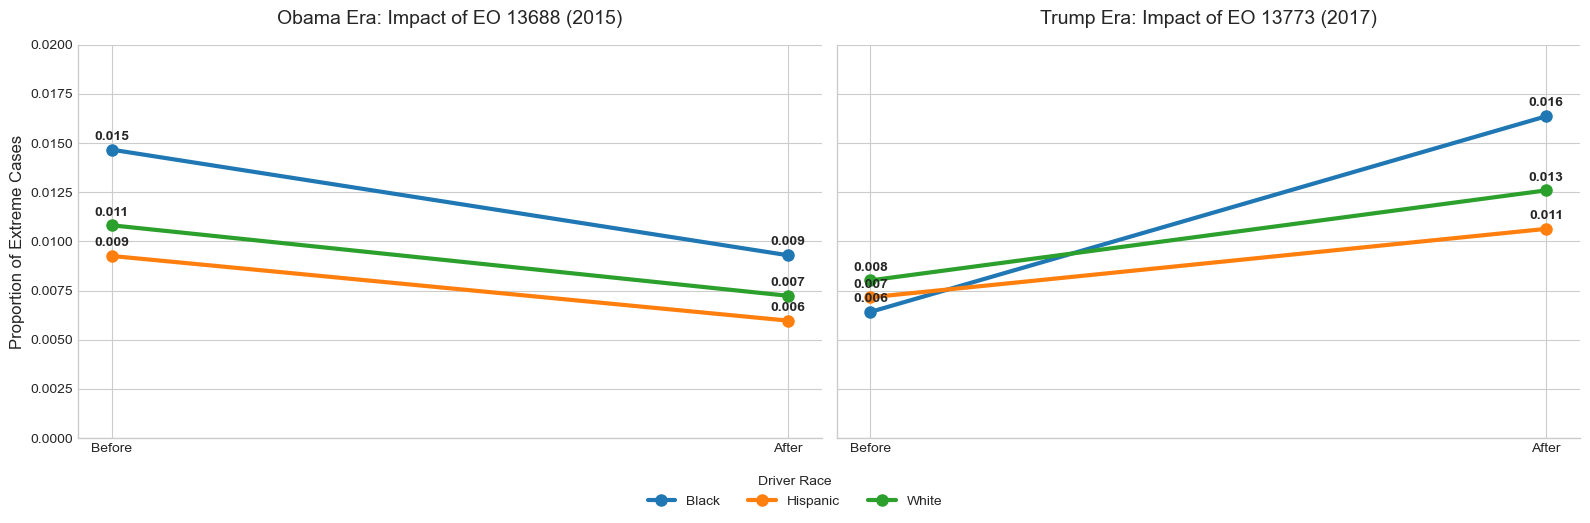

In [13]:
import matplotlib.pyplot as plt
import pandas as pd



plt.style.use('seaborn-v0_8-whitegrid')
colors = {'Black': '#1f77b4', 'Hispanic': '#ff7f0e', 'White': '#2ca02c'}

# 2. Create the side-by-side layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# --- PANEL 1: OBAMA ERA ---
for race in ['Black', 'Hispanic', 'White']:
    subset = prop_obama[prop_obama['subject_race'] == race].sort_values('eo_13688_active')
    # Mapping 0/1 to 'Before'/'After' for the X-axis
    x_labels = ['Before', 'After']
    ax1.plot(x_labels, subset['extreme_cases'], marker='o', markersize=8, linewidth=3, color=colors[race], label=race)
    
    
    for x, y in zip(x_labels, subset['extreme_cases']):
        ax1.text(x, y + 0.0005, f'{y:.3f}', ha='center', fontweight='bold')

ax1.set_title('Obama Era: Impact of EO 13688 (2015)', fontsize=14, pad=15)
ax1.set_ylabel('Proportion of Extreme Cases', fontsize=12)

# --- PANEL 2: TRUMP ERA ---
for race in ['Black', 'Hispanic', 'White']:
    subset = prop_trump[prop_trump['subject_race'] == race].sort_values('eo_13773_active')
    x_labels = ['Before', 'After']
    ax2.plot(x_labels, subset['extreme_cases'], marker='o', markersize=8, linewidth=3, color=colors[race])
    
    for x, y in zip(x_labels, subset['extreme_cases']):
        ax2.text(x, y + 0.0005, f'{y:.3f}', ha='center', fontweight='bold')

ax2.set_title('Trump Era: Impact of EO 13773 (2017)', fontsize=14, pad=15)

# 3. Final Polish
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 0.02) # Keeps the scale consistent for comparison


handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, title='Driver Race', bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 1]) 



plt.show()


In [23]:

fig.savefig('/Users/arjunrajesh/Desktop/graph.png', dpi=300, bbox_inches='tight')


In [18]:

plt.savefig('/Users/arjunrajesh/Desktop/graph.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
san_antonio_final.to_csv('san_antonio_final_data.csv', index=False)